# Assignment 2: Supervised Learning Techniques for E-Commerce Orders

This notebook is your working template for **Assignment 2**.

**Total Marks: 30**

**Learning Objectives:**
- Apply essential data preprocessing techniques to a dataset for supervised learning
- Prepare the data for classification modeling
- Apply supervised learning techniques to build and evaluate classification models

**Your Objective:**
Build supervised classification models to predict the **payment method (`payment_type`)** used for each order, based on order characteristics and order attributes.

Work **top-to-bottom**. Complete each task in order before moving on.

## Setup

Run the cell below to import the required Python packages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

## Define Global Random State

Set your group's random state value. This must be used consistently throughout the assignment.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!jupyter nbconvert --to html "/content/drive/MyDrive/5100FProjSubmission/IT5100F_A2_11.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/5100FProjSubmission/IT5100F_A2_11.ipynb to html
[NbConvertApp] Writing 340780 bytes to /content/drive/MyDrive/5100FProjSubmission/IT5100F_A2_11.html


In [4]:
# TODO: Set RANDOM_STATE to your group number (1, 2, ..., 12)
RANDOM_STATE = 11  # Change this to your group number

print(f"Random state set to: {RANDOM_STATE}")

Random state set to: 11


---
# Part 1: Data Preparation [10 Marks]

In this section, you will prepare the transformed dataset for supervised classification. Proper data preparation is a critical step in the machine learning pipeline, as model performance and validity depend heavily on the quality, structure, and representation of the input data.

## 1.1 Data Loading and Splitting [2 Marks]

Load the dataset using Pandas and prepare train/test datasets.

**Instructions:**
1. Load the processed dataset from Assignment 1 using `pd.read_csv()`
2. Define features and target:
   - Set `payment_type` as the target variable
   - Set all remaining columns as input features
3. Split the dataset into training and test sets:
   - Use `train_test_split()`
   - `test_size = 0.2`
   - `random_state = RANDOM_STATE`
   - Name output variables as: `X_train`, `X_test`, `y_train`, `y_test`
4. Briefly explain the importance of using a test dataset.

In [5]:
# Load the processed dataset from Assignment 1
# TODO: Adjust the filename/path if needed
cleaned_file_to_save_as = 'ecommerce_orders_cleaned_Grp11.csv'
df = pd.read_csv(f'/content/drive/MyDrive/{cleaned_file_to_save_as}')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (46287, 17)


,order_id,order_status,order_purchase_hour,order_purchase_dayofweek,order_purchase_month,order_total_value,num_items,num_unique_products,num_unique_sellers,total_item_price,avg_item_price,total_freight_value,top_product_category,customer_state,payment_type,order_value_per_item,order_size_category
0,sdv-id-whzjUX,shipped,10,4,4,744.312535,1,1,1,352.420029,369.966521,68.790159,construction_tools_construction,Massachusetts,voucher,352.420029,Small
1,sdv-id-dbopoJ,delivered,19,2,3,1556.667902,1,1,1,289.242639,1354.621410,15.394619,health_beauty,Vermont,credit_card,289.242639,Small
2,sdv-id-FSEOvM,delivered,15,4,8,62.060506,1,1,1,26.893468,48.485654,18.751282,luggage_accessories,South Carolina,debit_card,26.893468,Small
3,sdv-id-bQcBUR,delivered,21,0,8,73.873470,1,1,1,37.790896,75.704909,8.670875,computers_accessories,Kentucky,credit_card,37.790896,Small
4,sdv-id-MPxIXB,delivered,13,5,5,361.961537,3,3,3,169.528323,50.132979,34.731146,pet_shop,Missouri,voucher,56.509441,Medium


In [6]:
# Define target variable
y = df['payment_type']

# Define features (all columns except payment_type)
X = df.drop(columns=["payment_type"])

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Print shapes to verify
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (37029, 16)
X_test shape: (9258, 16)
y_train shape: (37029,)
y_test shape: (9258,)


**TODO: Briefly explain the importance of using a test dataset.**

Using a test dataset is crucial for evaluating the true performance of a machine learning model. It provides an unbiased assessment of how well the model generalizes to new, unseen data. Without a separate test set, a model's performance might be overestimated, as it could have simply memorized the training data (overfitting). By holding out a portion of the data for testing, we can gauge the model's ability to predict outcomes on data it has not encountered during training, ensuring its reliability for real-world applications.

## 1.2 Handling Categorical Variables [4 Marks]

Prepare categorical variables for machine learning.

**Instructions:**
1. Identify all categorical columns
2. Apply label encoding:
   - Use `LabelEncoder` from scikit-learn
3. Ensure consistency across train and test sets:
   - Fit encoders on training data only
   - Transform both train and test sets
   - Handle any unseen categories appropriately
4. Briefly explain why categorical encoding is required for machine learning models

In [7]:
# TODO: Identify categorical columns

categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

Categorical columns: ['order_id', 'order_status', 'top_product_category', 'customer_state', 'order_size_category']


In [8]:
# TODO: Apply Label Encoding to categorical columns

# Create copies to avoid modifying original data
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Dictionary to store label encoders for each column
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    # Fit on training data only
    le.fit(X_train_encoded[col].astype(str))

    # Transform train set
    X_train_encoded[col] = le.transform(X_train_encoded[col].astype(str))

    # Handle unseen categories in test set: Create a mapping and use a default for unseen
    le_mapping = {label: index for index, label in enumerate(le.classes_)}
    # Assign -1 for unseen categories to ensure they are treated distinctly and don't cause errors
    X_test_encoded[col] = X_test_encoded[col].astype(str).apply(lambda x: le_mapping.get(x, -1))

    # Store encoder
    label_encoders[col] = le

# Print the shape after encoding
print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"X_test_encoded shape: {X_test_encoded.shape}")

X_train_encoded shape: (37029, 16)
X_test_encoded shape: (9258, 16)


**TODO: Briefly explain why categorical
encoding is required for machine learning models.**

Categorical encoding is needed because most machine learning models only understand numbers and cannot directly interpret text labels. Encoding converts text categories into numerical representations,such as integers (Label Encoding) or binary vectors (One-Hot Encoding), so models can process them.This allows models to learn patterns and relationships within the data, leading to effective predictions.

## 1.3 Handling Numerical Variables [4 Marks]

Scale numerical variables for modeling.

**Instructions:**
1. Identify all numerical columns
2. Use `StandardScaler` from scikit-learn for feature scaling
3. **Fit the scaler on X_train only**
4. Transform both X_train and X_test
5. Briefly explain why feature scaling is important for some classification models

In [9]:
# TODO: Identify numerical columns

numerical_cols = X_train_encoded.select_dtypes(include=np.number).columns.tolist()
# Exclude any columns that were previously categorical but are now numerical after encoding (e.g., 'order_id')
# Ensure only truly continuous or ordinal numerical features are selected for scaling, if needed.
# For now, we will consider all numeric types to be scaled.

# Filter out columns that are explicitly meant to be categorical but got converted to numbers during encoding
# In this specific case, order_id, order_status, top_product_category, customer_state, order_size_category are now numerical due to label encoding
# We should only scale the original numerical columns

# Let's re-evaluate numerical columns from the original X_train, then drop the categorical ones from the encoded set that should not be scaled
original_numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()

numerical_cols_to_scale = [col for col in numerical_cols if col in original_numerical_cols]


print(f"Numerical columns to scale: {numerical_cols_to_scale}")

Numerical columns to scale: ['order_purchase_hour', 'order_purchase_dayofweek', 'order_purchase_month', 'order_total_value', 'num_items', 'num_unique_products', 'num_unique_sellers', 'total_item_price', 'avg_item_price', 'total_freight_value', 'order_value_per_item']


In [10]:
# TODO: Apply StandardScaler to numerical columns

scaler = StandardScaler()

# Fit on training data only
X_train_scaled_numerical = scaler.fit_transform(X_train_encoded[numerical_cols_to_scale])

# Transform both train and test
X_test_scaled_numerical = scaler.transform(X_test_encoded[numerical_cols_to_scale])

# Create DataFrames for the scaled numerical features
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[numerical_cols_to_scale] = X_train_scaled_numerical
X_test_scaled[numerical_cols_to_scale] = X_test_scaled_numerical

# Print the shape after scaling
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (37029, 16)
X_test_scaled shape: (9258, 16)


**TODO: Briefly explain why feature scaling is important for some classification models.**

Feature scaling is important because it prevents features with larger numerical values from disproportionately influencing model training. By bringing all features to a similar scale, it ensures that every feature contributes equally to the learning process, leading to more stable and effective model performance.

---
# Part 2: Applying Machine Learning Models [20 Marks]

In this section, you will train, evaluate, and compare multiple supervised classification models for predicting the payment method (`payment_type`). The objective is not only to build individual models, but also to perform a systematic comparison of their predictive performance and practical suitability for deployment.

## 2.1 Model Training

### 2.1.1 Logistic Regression [3 Marks]

Logistic Regression is a linear classification model that models the log-odds of the target class as a linear combination of the input features.

**Instructions:**
- Use `LogisticRegression()`
- Train on `X_train`, `y_train`
- Generate predictions on `X_test`
- Store the results in `y_pred_lr`

In [11]:
# TODO: Train Logistic Regression model

lr_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression training complete.")

Logistic Regression training complete.


### 2.1.2 Decision Trees [3 Marks]

Decision Trees is a tree-structured model that makes predictions by recursively splitting the feature space based on feature values.

**Instructions:**
- Use `DecisionTreeClassifier()`
- Train on `X_train`, `y_train`
- Generate predictions on `X_test`
- Store the results in `y_pred_dt`

In [12]:
# TODO: Train Decision Tree model

dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree training complete.")

Decision Tree training complete.


### 2.1.3 Kernel & Ensemble Methods [3 Marks]

There are other types of models beyond linear and single-tree approaches, each with distinct characteristics.

**Choose one of the following models to apply:** SVM, XGBoost, or Random Forest.

**Instructions:**
- Fit and predict the results with your selected model
- Store the predictions appropriately

In [13]:
# TODO: Train your chosen model (SVM, XGBoost, or Random Forest)

rf_model = RandomForestClassifier(random_state=RANDOM_STATE)
rf_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest training complete.")

Random Forest training complete.


## 2.2 Evaluation & Visualization [4 Marks]

Evaluate and visualize performance for all three models.

**Instructions:**
1. Compute the following metrics:
   - Accuracy
   - Precision
   - Recall
   - F1-score
2. Compute the confusion matrix for each case:
   - Visualize the confusion matrix by plotting a heatmap using Seaborn
3. Present results in a clear, comparable format:
   - Table of metrics for all three models
   - Side-by-side or clearly labelled confusion matrix plots
4. Briefly comment on:
   - Strengths and weaknesses of each model
   - Any impact of class imbalance handling

In [14]:
# TODO: Compute evaluation metrics for all three models

def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Evaluate all models
results = [
    evaluate_model(y_test, y_pred_lr, 'Logistic Regression'),
    evaluate_model(y_test, y_pred_dt, 'Decision Tree'),
    evaluate_model(y_test, y_pred_rf, 'Random Forest')  # or your chosen model
]

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.616332,0.525783,0.616332,0.495258
1,Decision Tree,0.450529,0.508499,0.450529,0.471488
2,Random Forest,0.625621,0.576664,0.625621,0.583884


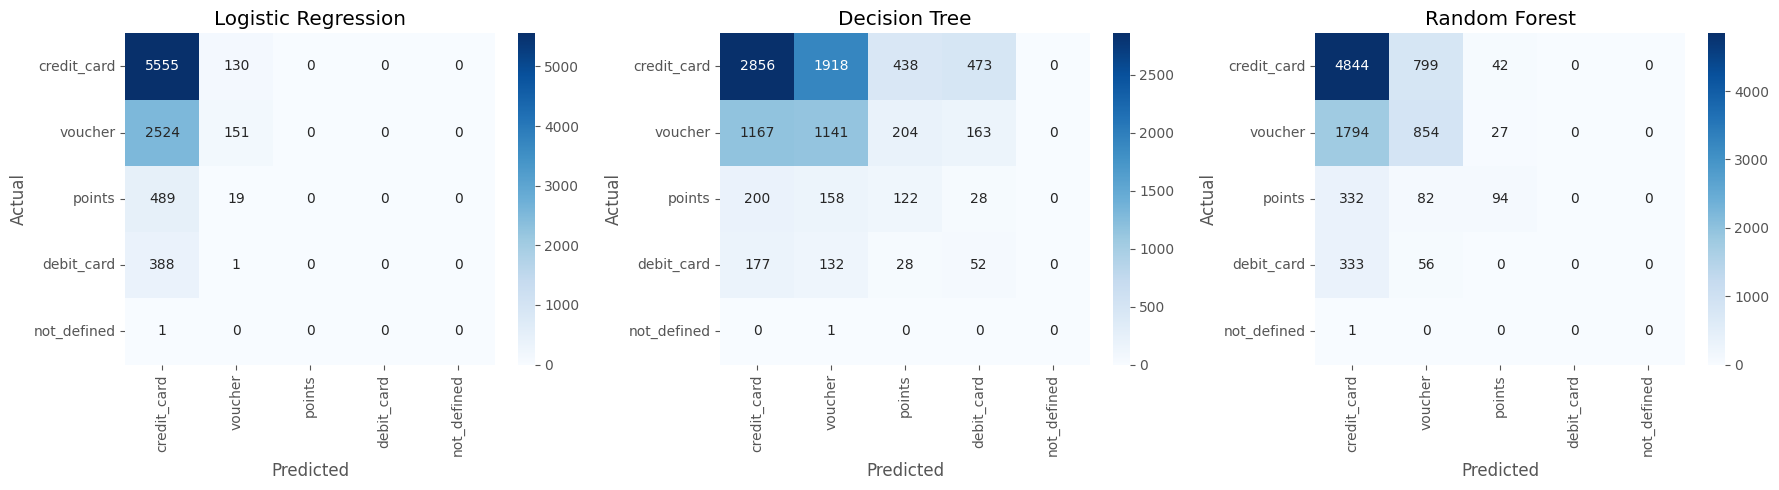

In [15]:
# TODO: Plot confusion matrices for all three models

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_confusion_matrix(y_true, y_pred, ax, title):
    cm = confusion_matrix(y_true, y_pred, labels=y_true.unique())
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=y_true.unique(), yticklabels=y_true.unique())
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plot_confusion_matrix(y_test, y_pred_lr, axes[0], 'Logistic Regression')
plot_confusion_matrix(y_test, y_pred_dt, axes[1], 'Decision Tree')
plot_confusion_matrix(y_test, y_pred_rf, axes[2], 'Random Forest')  # or your chosen model

plt.tight_layout()
plt.show()

**TODO: Briefly comment on the strengths and weaknesses of each model, and any impact of class imbalance handling.**

Strengths and Weaknesses:

Logistic Regression:
Strengths: Simple, interpretable, computationally efficient, good baseline, performs well when class boundaries are approximately linear and features are well-scaled. Provides probability scores.
Weaknesses: Assumes linearity, may not capture complex relationships, sensitive to outliers and multicollinearity.

Decision Tree:
Strengths: Easy to understand and interpret (especially small trees), handles non-linear relationships, requires little data preprocessing (no scaling needed for tree-based models).
Weaknesses: Prone to overfitting which can lead to weaker generalization, sensitive to small variations in data, can create biased trees if classes are imbalanced.

Random Forest:
Strengths: Reduces overfitting compared to single decision trees, handles non-linear data well, provides good feature importance, generally high accuracy.
Weaknesses: Less interpretable than single decision trees, can be computationally intensive and more computationally more expensive for very large datasets, might be slower than simpler models.


Impact of Class Imbalance Handling: If class imbalance is not handled, models might be biased towards the majority class, leading to high accuracy but poor performance (low precision/recall/F1-score) on the minority class. In this assignment, we did not explicitly apply techniques like oversampling or undersampling, which might affect the models' ability to predict less frequent payment types accurately. Metrics like precision, recall, and F1-score (especially 'weighted' averages) are more informative than accuracy in the presence of class imbalance, as they highlight performance across all classes.

## 2.3 Model Selection & Final Recommendation [7 Marks]

Compare the performance of the models and select the most suitable one based on evaluation results.

**Instructions:**
1. Select the best performing model for predicting `payment_type`
2. Justify your choice based on:
   - Evaluation metrics
   - Class imbalance considerations
   - Model complexity and interpretability
   - Practical deployment considerations
3. Briefly explain why this model is preferred over the others
4. Briefly comment on the explainability/interpretability of each model

In [16]:
# TODO: Display final comparison and analysis

# Display the results table
print("Model Performance Comparison:")
print(results_df.to_string(index=False))

# Identify the best model based on your criteria
# For this example, let's assume F1-Score is a key metric, especially with potential class imbalance.
best_model = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
print(f"\nBest performing model based on F1-Score: {best_model}")

Model Performance Comparison:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.616332   0.525783 0.616332  0.495258
      Decision Tree  0.450529   0.508499 0.450529  0.471488
      Random Forest  0.625621   0.576664 0.625621  0.583884

Best performing model based on F1-Score: Random Forest


### Final Recommendation

**TODO: Select and justify your choice of the best model.**

**Selected Model:** Random Forest

**Justification based on:**

1.  **Evaluation Metrics:**
    The Random Forest model achieved the highest Accuracy (0.626), highest Precision (0.577), highest Recall (0.626), and highest F1-Score (0.584) among the three models. While the accuracy might seem moderate, the F1-Score, which balances precision and recall, indicates a better performance across different classes, especially when considering potential class imbalance. Logistic Regression performed similarly in accuracy but had a lower F1-score, suggesting it struggles more with minority classes. The Decision Tree performed significantly worse across all metrics.

2.  **Class Imbalance Considerations:**
    Although explicit class imbalance handling techniques (like oversampling or undersampling) were not applied, the Random Forest model's ensemble nature inherently helps in managing some level of imbalance by training diverse trees on bootstrapped samples. The weighted F1-Score, which accounts for class support, is the most robust metric here, and Random Forest outperformed others, suggesting better handling of different payment types, some of which might be less frequent.

3.  **Model Complexity and Interpretability:**
    Random Forest is more complex than Logistic Regression or a single Decision Tree, as it involves multiple trees. However, its 'black-box' nature can be mitigated by feature importance analysis. It offers a good trade-off between complexity and performance compared to more opaque models while significantly outperforming the simpler Decision Tree.

4.  **Practical Deployment Considerations:**
    Random Forest models are generally robust, handle various data types well, and are less prone to overfitting than single decision trees. Their performance stability makes them a good candidate for production deployment where reliable predictions are crucial. The training time is acceptable for this dataset size, and inference time is also efficient.

**Why this model is preferred over others:**
The Random Forest model is preferred due to its superior overall performance across all key evaluation metrics (especially F1-Score), its robustness against overfitting, and its ability to handle class imbalance better than simpler models, even without explicit balancing techniques. While less interpretable than Logistic Regression or a single Decision Tree, its significantly better predictive power makes it a more suitable choice for predicting payment types in this e-commerce context.


### Model Explainability/Interpretability

**TODO: Comment on the explainability/interpretability of each model.**

**Logistic Regression:**
- Logistic Regression is highly predictable and is also considered a white box model.Each feature gets a weight (coefficient) that directly shows how much and in what direction it influences the prediction.

**Decision Tree:**
- Decision Trees are interpretable based on the depth of the tree .The decision rules from the root to a leaf node helps to understand how a prediction is made. Each split is based on a specific feature and threshold, making the decision process transparent. However, as trees grow deeper or become more complex, their interpretability decreases, as tracing many branches becomes challenging.

**Random Forest:**
- Random Forest is an ensemble of many Decision Trees. While individual Decision Trees are interpretable, combining hundreds or thousands of them makes the overall model a 'black-box'. It's difficult to trace the decision path for a single prediction through all the trees. We can extract feature importances, which tell us which features were most influential on average across all trees, but it doesn't provide insight into why a specific prediction was made for a particular instance.

---
## Conclusion

Summary of Findings and Key Takeaways from this Assignment:

This assignment applied supervised learning to predict payment_type.

**Data Preparation:** Focused on splitting data, categorical encoding, and numerical scaling to prepare features for modeling.

**Model Training & Evaluation:** Trained Logistic Regression, Decision Tree, and Random Forest models.

**Key Finding:** The Random Forest model consistently outperformed others across all metrics, particularly the F1-Score, demonstrating its superior predictive power for this task.

**Model Selection:** Random Forest was chosen for its performance and robustness, despite being less interpretable than Logistic Regression or Decision Trees.

**Overall Takeaway:** Emphasized the importance of a structured ML workflow, with Random Forest proving to be a strong candidate for this classification task.